In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import highdicom as hd
import pydicom as pd
from pydicom.sr.codedict import codes
import numpy as np
import circle_fit 
import skimage.draw
import imageio

## Define input files and target pixel spacing

In [16]:
# input file
# image_file_base = 'OAI-9005321-V10-20120822'
# image_file_base = '0383999_T02_APO'
# image_file_base = 'OAI-9000099-V06-20090728'
# image_file_base = '0003088_T10_APO'
# image_file_base = '0003088_T10_APO'
# image_file_base = '1463528_T02_APO'
# image_file_base = 'OAI-9003175-V06-20090723'
image_file_base = 'data/sample/0026001_T00_APO'

image_file_dicom = f'{image_file_base}.dcm'
image_file_points = f'{image_file_dicom}.pts'

# output file
image_file_segmentation = f'{image_file_base}--segmentation.dcm'

In [17]:
# set to mm/pixel, or None to disable resampling
target_pixel_spacing = None  # 0.4

## Loading data

Image size: (2048, 2494)


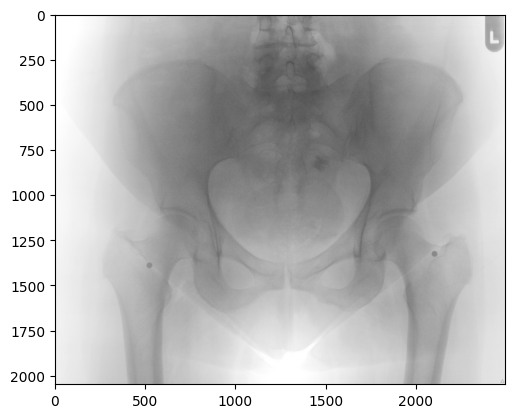

In [18]:
# load image
img = pd.dcmread(image_file_dicom)
plt.imshow(img.pixel_array, 'gray')
print(f"Image size: {img.pixel_array.shape}")

In [20]:
# load points from BoneFinder
# coordinates are defined in mm
points = []
with open(image_file_points, 'r') as f:
    # skip until start of points: line with {
    line = f.readline()
    while line and line.strip() != '{':
        line = f.readline()
    points = []
    # read points until end: line with }
    line = f.readline()
    while line and line.strip() != '}':
        points.append([float(i) for i in line.strip().split(' ')])
        line = f.readline()
print(f"Number of points: {len(points)}")
points = np.array(points)

Number of points: 160


In [21]:
# extract pixel spacing (mm/pixel) from the DICOM headers
source_pixel_spacing = img.get('PixelSpacing') or img.get('ImagerPixelSpacing')
assert source_pixel_spacing is not None, 'no pixel spacing found'
assert source_pixel_spacing[0] == source_pixel_spacing[1], 'asymmetric pixel spacing is untested'
pixel_spacing = source_pixel_spacing
print('Input pixel spacing:', source_pixel_spacing)

Input pixel spacing: [1.70000000E-01, 1.70000000E-01]


## Resample image to the target resolution, apply DICOM settings

In [22]:
print(img)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 196
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Computed Radiography Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.51.5145.2056.20040323.1102608.1.0.1
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.113654.2.3.1995.3.0.6
(0002,0013) Implementation Version Name         SH: 'GDCM 2.4.5'
(0002,0016) Source Application Entity Title     AE: 'gdcmanon'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0012) Instance Creation Date              DA: '20040101'
(0008,0013) Instance Creation Time              TM: ''
(0008,0016) SOP Class UID                       UI: Com

In [23]:
# resample to the required resolution
if target_pixel_spacing is not None:
    scale_factor = source_pixel_spacing[0] / target_pixel_spacing
    print('Scaling factor:', scale_factor)
    
    print('Source image size:', img.pixel_array.shape)
    img_pixels = skimage.transform.rescale(img.pixel_array, scale_factor)
    print('Resized image size:', img_pixels.shape)
    
    pixel_spacing = [target_pixel_spacing, target_pixel_spacing]
else:
    img_pixels = img.pixel_array

# are the intensities stored as MONOCHROME2 (white=max, black=min) or
# as MONOCHROME1 (white=min, black=max)?
photometric_interpretation = img.get('PhotometricInterpretation')
if photometric_interpretation == 'MONOCHROME1':
    print('Photometric interpretation MONOCHROME1: inverting intensities')
    img_pixels = np.max(img_pixels) - img_pixels
else:
    assert photometric_interpretation == 'MONOCHROME2',\
        f'{photometric_interpretation} not supported'

# other checks
assert img.get('VOILUTFunction', 'LINEAR') == 'LINEAR', \
    'only supporting VOILUTFunction LINEAR'

Photometric interpretation MONOCHROME1: inverting intensities


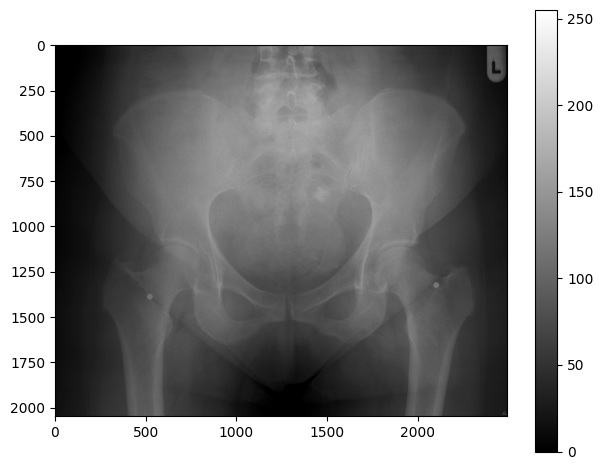

In [24]:
plt.imshow(img_pixels, cmap='gray')
plt.colorbar()
plt.tight_layout()

## Plotting points and curves

In [25]:
# define the curves: right first, then left
SIDES = { 'right': 0, 'left': 80 }
CURVES = {
    'proximal femur':     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
                           19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34],
    'greater trochanter': [6, 35, 36, 37, 38, 39],
    'posterior wall':     [40, 41, 42, 43, 44],
    'ischium and pubis':  [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60],
    'foramen':            [60, 61, 62, 63, 64, 65, 66],
    'acetabular roof':    [67, 68, 69, 70, 71, 72, 73, 74],
    'teardrop':           [75, 76, 77, 78, 79],
}
SUB_CURVES = {
    'femoral head':       [18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
    'sourcil':            [70, 71, 72, 73, 74],
}

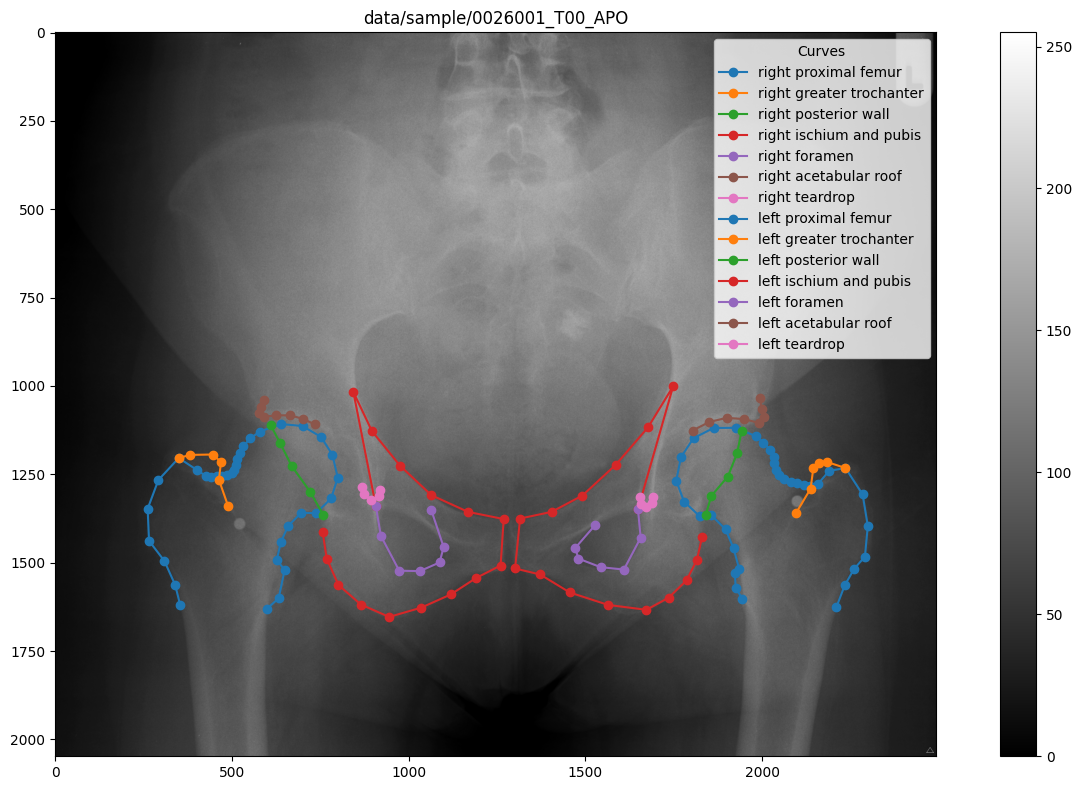

In [26]:
# plot the image with superimposed curves
plt.figure(figsize=(13, 8))
plt.imshow(img_pixels, cmap='gray')
plt.colorbar()

# plot curves for right and left
for side, offset in SIDES.items():
    for idx, (name, curve) in enumerate(CURVES.items()):
        color = plt.rcParams['axes.prop_cycle'].by_key()['color'][idx]
        plt.plot(*(points[np.array(curve) + offset] / pixel_spacing).transpose(),
                 marker='o', color=color,
                 label=f'{side} {name}',)
plt.title(image_file_base)
plt.legend(title='Curves')
plt.tight_layout()

## Polygons to mask

Convert the polygons to a pixel mask.

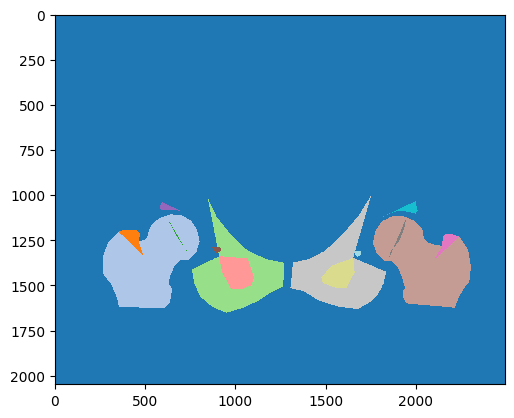

In [27]:
combined_mask = np.zeros(shape=img_pixels.shape, dtype=np.uint8)

c_idx = 0
for side, offset in SIDES.items():
    for idx, (name, curve) in enumerate(CURVES.items()):
        c_idx += 1
        mask = skimage.draw.polygon2mask(
            img_pixels.shape,
            (points[np.array(curve) + offset] / pixel_spacing)[:, [1, 0]]
        )
        combined_mask[mask] = c_idx

plt.figure()
plt.imshow(combined_mask, cmap='tab20', interpolation='none');

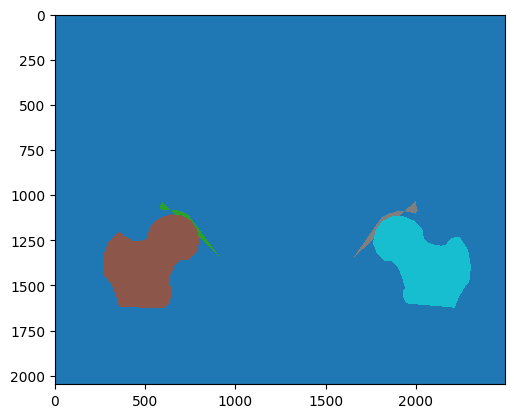

In [28]:
combined_mask = np.zeros(shape=img_pixels.shape, dtype=np.uint8)

mask_region_curves = {
    #                       topmost point of ischium & pubis curve
    'acetabular roof': CURVES['acetabular roof'] + [60],
    'proximal femur':  CURVES['proximal femur'],
}

c_idx = 0
for side, offset in SIDES.items():
    for idx, (name, curve) in enumerate(mask_region_curves.items()):
        c_idx += 1
        mask = skimage.draw.polygon2mask(
            img_pixels.shape,
            (points[np.array(curve) + offset] / pixel_spacing)[:, [1, 0]]
        )
        combined_mask[mask] = c_idx

plt.figure()
plt.imshow(combined_mask, cmap='tab10', interpolation='none');

## Fitting circles to femoral head and sourcil

Fit a circle to the circular part of the femoral head, in order to determine the center of the femoral head.

In [29]:
# fit circles to femoral head and sourcil
sides = { 'right': 0, 'left': 80 }
curves = {
    'femoral head':       [18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
    'sourcil':            [70, 71, 72, 73, 74],
}
circles = {}
for side, offset in SIDES.items():
    for name, curve in SUB_CURVES.items():
        xc, yc, r, sigma = circle_fit.taubinSVD(points[np.array(curve) + offset])
        circles[f'{side} {name}'] = { 'xc': xc, 'yc': yc, 'r': r, 'sigma': sigma }

print('Fitted circles:')
for name, circle in circles.items():
    print(f' {name}: {circle}')

Fitted circles:
 right femoral head: {'xc': np.float64(111.27056642327038), 'yc': np.float64(212.22858476579916), 'r': np.float64(24.259573342806664), 'sigma': np.float64(0.3254285925926663)}
 right sourcil: {'xc': np.float64(108.31874503333285), 'yc': np.float64(216.6447333144223), 'r': np.float64(32.74748037869762), 'sigma': np.float64(0.10595114366336576)}
 left femoral head: {'xc': np.float64(322.96504613673915), 'yc': np.float64(213.13488296263415), 'r': np.float64(23.855251625904508), 'sigma': np.float64(0.3233130978699068)}
 left sourcil: {'xc': np.float64(325.93499306679354), 'yc': np.float64(219.00167961851756), 'r': np.float64(33.67378919352529), 'sigma': np.float64(0.10250029881928165)}


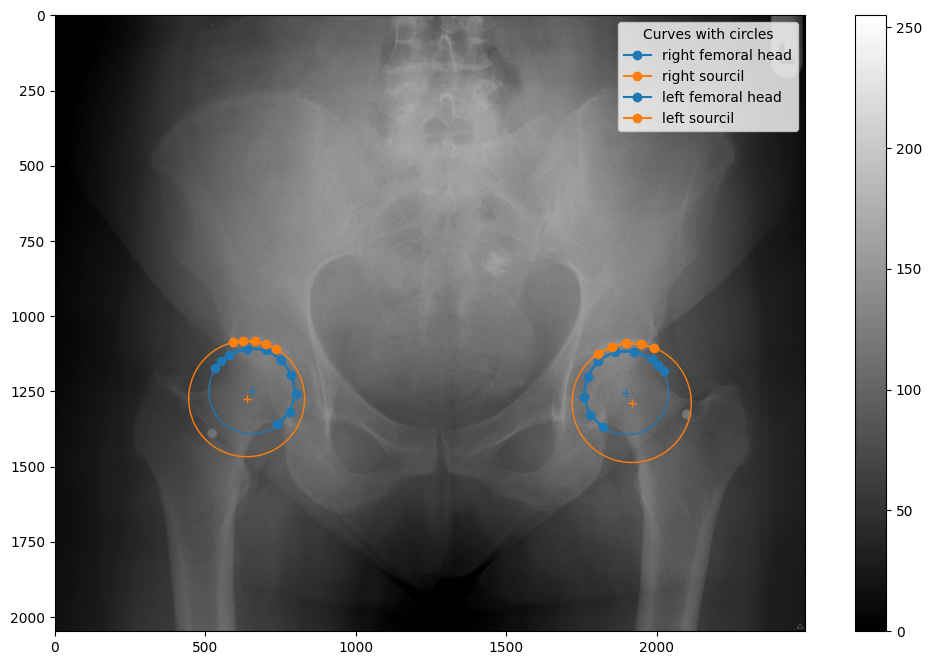

In [30]:
# plot circles 
plt.figure(figsize=(13, 8))
plt.imshow(img_pixels, cmap='gray')
plt.colorbar()

for side, offset in SIDES.items():
    for idx, (name, curve) in enumerate(SUB_CURVES.items()):
        color = plt.rcParams['axes.prop_cycle'].by_key()['color'][idx]
        curve = np.array(curve) + offset
        # points
        plt.plot(points[curve, 0] / pixel_spacing[0],
                 points[curve, 1] / pixel_spacing[1],
                 marker='o', color=color,
                 label=f'{side} {name}',)
        # circle
        circle = circles[f'{side} {name}']
        theta_fit = np.linspace(-np.pi, np.pi, 180)
        x_fit = circle['xc'] + circle['r'] * np.cos(theta_fit)
        y_fit = circle['yc'] + circle['r'] * np.sin(theta_fit)
        plt.plot(x_fit / pixel_spacing[0], y_fit / pixel_spacing[1], color=color, linewidth=1)
        plt.plot(circle['xc'] / pixel_spacing[0],
                 circle['yc'] / pixel_spacing[1],
                 '+', color=color)
plt.legend(title='Curves with circles');

## Joint-space segmentation mask

Create a multi-class segmentation image, with background, acetabulum, femur, and joint space.

The segmentation is only defined within a bounding box around the joint space.

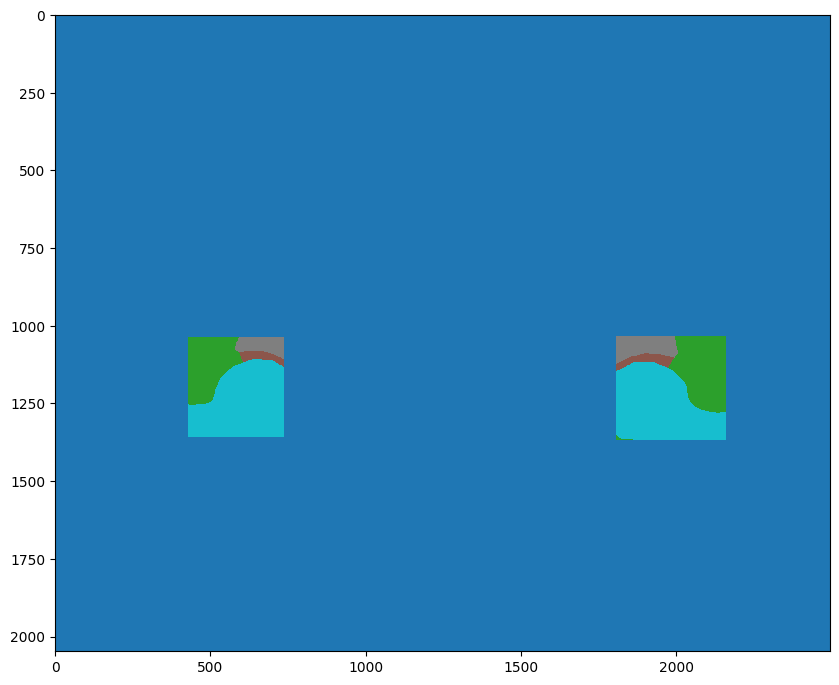

In [32]:
combined_mask = np.zeros(shape=img_pixels.shape, dtype=np.uint8)
fg_mask = np.zeros_like(combined_mask, dtype=bool)

LABELS = {
    'ignore': 0,
    'background': 1,
    'acetabulum': 2,
    'femur': 3,
    'joint space': 4,
}

# background label inside the bounding box
combined_mask[:] = LABELS['background']

js_bbox = {}

for side, offset in SIDES.items():
    # define the bounding box of the segmentation region
    js_bbox[side] = bbox = {
        # top: topmost point of acetabulum curve
        'top': points[67 + offset][1],
        # medial: most medial point of the sourcil
        'medial': points[74 + offset][0],
        # lateral:
        'lateral': points[8 + offset][0],
        # bottom: medial bottom of femoral head
        'bottom': points[27 + offset][1],
    }

    # include bbox in foreground/background mask
    fg_mask[skimage.draw.polygon2mask(
        fg_mask.shape,
        np.array([
            [bbox['top'], bbox['lateral']],
            [bbox['bottom'], bbox['lateral']],
            [bbox['bottom'], bbox['medial']],
            [bbox['top'], bbox['medial']],
        ]) / np.array(pixel_spacing)[[1, 0]]
    )] = True

    # from most lateral part of the sourcil to center of femoral head
    circle = circles[f'{side} femoral head']

    # define the regions
    regions = {
        'joint space': np.array([
            # note: this polygon is larger than the joint space,
            # but the excess will be covered by the bone regions
            # - start from most lateral point of the sourcil
            points[70 + offset],
            # - to center of femoral head
            [circle['xc'], circle['yc']],
            # - to medial boundary of bbox
            [bbox['medial'], circle['yc']],
            # - to medial top
            [bbox['medial'], bbox['top']],
            # - to topmost point of acetabulum curve
            points[67 + offset],
        ]),
        'acetabulum': np.array([
            *points[np.array(CURVES['acetabular roof']) + offset],
            [bbox['medial'], bbox['top']],
        ]),
        'femur': np.array([
            *points[np.array(CURVES['proximal femur']) + offset],
        ]),
    }

    # add regions to mask
    for idx, (name, region) in enumerate(regions.items()):
        mask = skimage.draw.polygon2mask(
            combined_mask.shape,
            (region / pixel_spacing)[:, [1, 0]]
        )
        combined_mask[mask] = idx + 2

# set background outside bounding box
combined_mask[~fg_mask] = LABELS['ignore']

plt.figure(figsize=(10, 10))
plt.imshow(combined_mask, cmap='tab10', interpolation='nearest');

## Save as DICOM-SEG

Save the segmentation mask as DICOM-SEG file that can be shown on top of the original DICOM image.

In [33]:
if img.pixel_array.shape != img_pixels.shape:
    print('Pixel spacing changed; DICOM-SEG not saved.')
else:
    algorithm = hd.content.AlgorithmIdentificationSequence(
        name='BoneFinder ground truth',
        family=codes.cid7162.ArtificialIntelligence,
        version='1.0',
    )

    segment_descriptions = []
    for label, label_idx in LABELS.items():
        if label_idx > 0:
            segment_descriptions.append(hd.seg.SegmentDescription(
                segment_number=label_idx,
                segment_label=label,
                segmented_property_category=codes.SCT.Bone,
                segmented_property_type=codes.SCT.Bone,
                algorithm_type=hd.seg.SegmentAlgorithmTypeValues.AUTOMATIC,
                algorithm_identification=algorithm,
            ))

    seg_dataset = hd.seg.Segmentation(
        source_images=[img],
        pixel_array=combined_mask,
        segmentation_type=hd.seg.SegmentationTypeValues.FRACTIONAL,
        # BINARY doesn't work in Weavis, but FRACTIONAL is similar and does
        # segmentation_type=hd.seg.SegmentationTypeValues.BINARY,
        segment_descriptions=segment_descriptions,
        series_instance_uid=hd.UID(),
        series_number=2,
        sop_instance_uid=hd.UID(),
        instance_number=1,
        manufacturer='Example',
        manufacturer_model_name='Example',
        software_versions='v1',
        device_serial_number='N/A',
    )
        
    seg_dataset.save_as(image_file_segmentation)

d:\Jasper\School\Universiteit\Year_3\Research_Project\Code\anatamae\.venv\Lib\site-packages\highdicom\base.py:163: UserWarning: The string "anonymous" is unlikely to represent the intended person name since it contains only a single component. Construct a person name according to the format in described in https://dicom.nema.org/dicom/2013/output/chtml/part05/sect_6.2.html#sect_6.2.1.2, or, in pydicom 2.2.0 or later, use the pydicom.valuerep.PersonName.from_named_components() method to construct the person name correctly. If a single-component name is really intended, add a trailing caret character to disambiguate the name.
  check_person_name(patient_name)


## Crop hip ROIs

Crop the image and segmentation mask to 15 by 15 cm, centered on the femoral head.

In [34]:
# crop to 150 mm
roi_crop_size = 150 / pixel_spacing[0]

hip_roi_crops = {}
hip_seg_roi_crops = {}
for idx, side in enumerate(('right', 'left')):
    circle = circles[f'{side} femoral head']
    bbox = [
        slice(int(circle['yc'] / pixel_spacing[1] - roi_crop_size / 2),
              int(circle['yc'] / pixel_spacing[1] + roi_crop_size / 2)),
        slice(int(circle['xc'] / pixel_spacing[0] - roi_crop_size / 2),
              int(circle['xc'] / pixel_spacing[0] + roi_crop_size / 2)),
    ]
    hip_roi_crops[side] = img_pixels[*bbox]
    hip_seg_roi_crops[side] = combined_mask[*bbox]

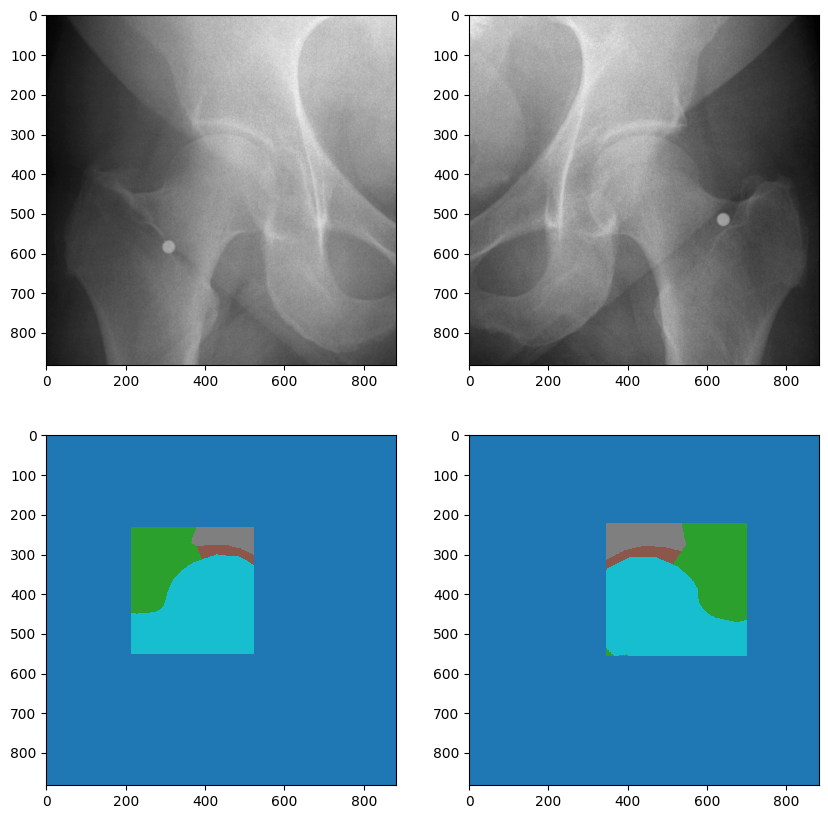

In [35]:
# plot cropped images and segmentations
plt.figure(figsize=(10, 10))
for idx, side in enumerate(('right', 'left')):
    plt.subplot(2, 2, idx + 1)
    plt.imshow(hip_roi_crops[side], cmap='gray')
    plt.subplot(2, 2, idx + 3)
    plt.imshow(hip_seg_roi_crops[side], cmap='tab10', interpolation='none')

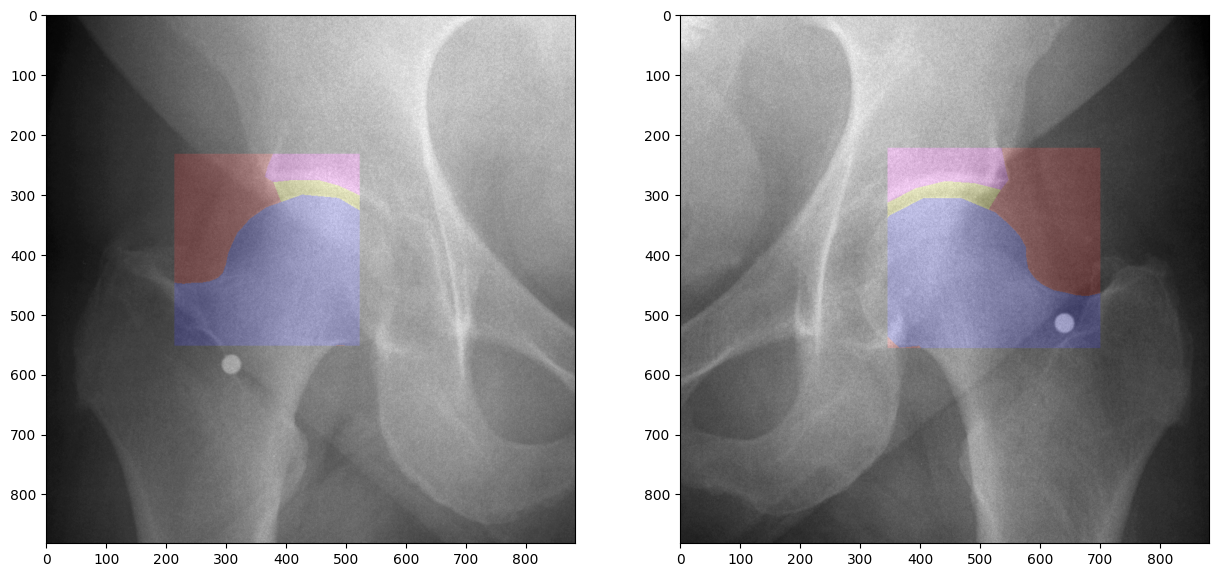

In [36]:
# plot image with segmentation overlay
COLORS = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [1, 1, 0],
    [1, 0, 1],
    [0, 0, 1],
])

plt.figure(figsize=(15, 7))
for idx, side in enumerate(('right', 'left')):
    rgb_img = np.repeat(hip_roi_crops[side][:, :, None], repeats=3, axis=2).astype(float)
    rgb_img -= rgb_img.min()
    rgb_img /= rgb_img.max()
    rgb_seg = COLORS[hip_seg_roi_crops[side], :]
    rgb = np.clip(rgb_img + rgb_seg * 0.15, 0, 1)
    plt.subplot(1, 2, idx + 1)
    plt.imshow(rgb)

## Crop joint-space ROIs

Crop the image to the bounding box of the joint-space segmentation plus 20 mm on each side.

In [37]:
margin = 20 / pixel_spacing[0]

js_roi_crops = {}
js_seg_roi_crops = {}
for idx, side in enumerate(('right', 'left')):
    bbox = np.array([
        [ min(js_bbox[side]['medial'], js_bbox[side]['lateral']),
          max(js_bbox[side]['medial'], js_bbox[side]['lateral']) ],
        [ js_bbox[side]['top'], js_bbox[side]['bottom'] ],
    ]) / pixel_spacing
    crop = [
        slice(int(bbox[1, 0] - margin), int(bbox[1, 1] + margin)),
        slice(int(bbox[0, 0] - margin), int(bbox[0, 1] + margin)),
    ]
    js_roi_crops[side] = img_pixels[*crop]
    js_seg_roi_crops[side] = combined_mask[*crop]

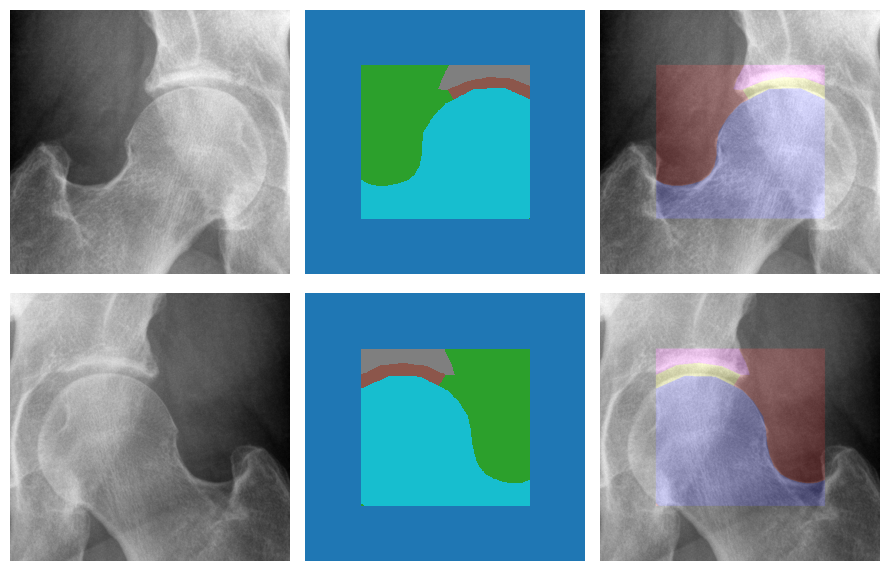

In [73]:
# plot cropped images and segmentations
plt.figure(figsize=(9, 6))
for idx, side in enumerate(('right', 'left')):
    plt.subplot(2, 3, 3 * idx + 1)
    plt.imshow(js_roi_crops[side], cmap='gray')
    plt.axis('off')
    plt.subplot(2, 3, 3 * idx + 2)
    plt.imshow(js_seg_roi_crops[side], cmap='tab10', interpolation='none')
    plt.axis('off')
    rgb_img = np.repeat(js_roi_crops[side][:, :, None], repeats=3, axis=2).astype(float)
    rgb_img -= rgb_img.min()
    rgb_img /= rgb_img.max()
    rgb_seg = COLORS[js_seg_roi_crops[side], :]
    rgb = np.clip(rgb_img + rgb_seg * 0.15, 0, 1)
    plt.subplot(2, 3, 3 * idx + 3)
    plt.imshow(rgb)
    plt.axis('off')
plt.tight_layout()

## Intensity normalization

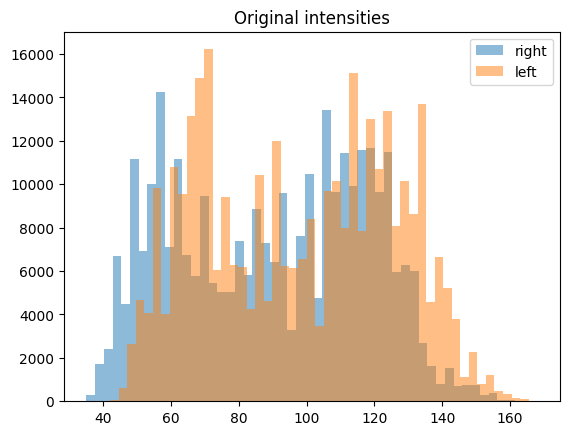

In [38]:
for side in SIDES:
    plt.hist(js_roi_crops[side].flatten(), bins=50, alpha=0.5, label=side)
plt.legend()
plt.title('Original intensities');

Text(0.5, 1.0, 'Intensities scaled to [0, 1]')

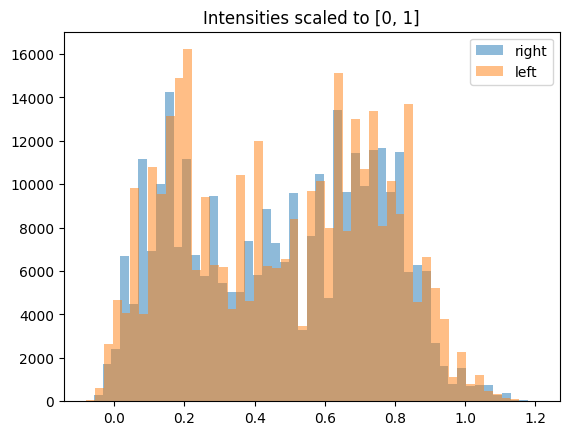

In [39]:
js_roi_crops_normalized = {}
for side in SIDES:
    x = js_roi_crops[side].astype(float)
    percentile = np.percentile(x.flatten(), [1, 99])
    x -= percentile[0]
    x /= percentile[1] - percentile[0]
    js_roi_crops_normalized[side] = x
    plt.hist(x.flatten(), bins=50, alpha=0.5, label=side)
plt.legend()
plt.title('Intensities scaled to [0, 1]')